# DeepLense Task VII: Physics-Informed Neural Networks (PINNs)
**Substructure Classification in Strong Gravitational Lensing**
**Author:** Vansh Jain

### Abstract
This notebook implements a Physics-Informed Neural Network (PINN) designed to classify dark matter substructures (no-sub, sphere, and vortex). By integrating the gravitational lensing equation $\beta = \theta - \alpha$ directly into the architecture, we enforce physical consistency and flux conservation.

**Compliance Note:** To meet the GSoC Task VII requirements, the official dataset (initially 80:20) has been re-stratified into a strict **90:10 train-test split** to ensure a more robust evaluation of the physical manifold.

In [1]:
import os, random, logging, sys, numpy as np, torch
import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.model_selection import train_test_split
from dataclasses import dataclass, field
from torch.optim.lr_scheduler import ReduceLROnPlateau

# --- ACADEMIC LOGGING ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s', stream=sys.stdout)
logger = logging.getLogger("DeepLense_TaskVII")

@dataclass
class PINNConfig:
    data_dir: Path = Path("/kaggle/input/datasets/vanshdistsys2/deeplense-specifictask-7-dataset/dataset")
    artifact_dir: Path = Path("/kaggle/working/artifacts")
    lambda_physics: float = 0.01 
    alpha_scaling_factor: float = 0.2
    learning_rate: float = 3e-4
    weight_decay: float = 1e-4
    batch_size: int = 32
    epochs: int = 150              
    input_channels: int = 1
    num_classes: int = 3
    class_mapping: dict[str, int] = field(default_factory=lambda: {"no": 0, "sphere": 1, "vort": 2})
    random_seed: int = 42

config = PINNConfig()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set seeds for reproducibility
random.seed(config.random_seed)
np.random.seed(config.random_seed)
torch.manual_seed(config.random_seed)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(config.random_seed)

### Phase 1: Automated Dataset Telemetry & Stratification
We aggregate all artifacts from the provided `train` and `val` partitions to create a unified pool of 37,500 samples. We then perform a stratified **90:10 split**, resulting in **33,750 training** and **3,750 validation** samples, strictly adhering to GSoC evaluation standards.

In [2]:
class LensingDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths, self.labels = file_paths, labels

    def __len__(self): return len(self.file_paths)

    def __getitem__(self, idx):
        arr = np.load(self.file_paths[idx]).astype(np.float32)
        # Global normalization
        a_min, a_max = arr.min(), arr.max()
        if a_max > a_min: arr = (arr - a_min) / (a_max - a_min)
        
        img_tensor = torch.from_numpy(arr)
        
        # FIX: Only add a channel dimension if the array is purely 2D (H, W)
        if img_tensor.dim() == 2:
            img_tensor = img_tensor.unsqueeze(0)
            
        return img_tensor, torch.tensor(self.labels[idx], dtype=torch.long)

def get_stratified_loaders(config):
    train_paths, train_labels = [], []
    for class_name, label_idx in config.class_mapping.items():
        class_dir = config.data_dir / 'train' / class_name
        if class_dir.exists():
            files = list(class_dir.glob("*.npy"))
            train_paths.extend(files)
            train_labels.extend([label_idx] * len(files))
            
    val_paths, val_labels = [], []
    for class_name, label_idx in config.class_mapping.items():
        class_dir = config.data_dir / 'val' / class_name
        if class_dir.exists():
            files = list(class_dir.glob("*.npy"))
            val_paths.extend(files)
            val_labels.extend([label_idx] * len(files))

    # Split validation set for true hold-out testing
    val_to_train_p, final_val_p, val_to_train_l, final_val_l = train_test_split(
        val_paths, val_labels, test_size=0.50, 
        random_state=config.random_seed, stratify=val_labels
    )
    
    final_train_paths = train_paths + val_to_train_p
    final_train_labels = train_labels + val_to_train_l
    
    logger.info(f"Leakage-Free Compliance Check -> Train: {len(final_train_paths)} | Val: {len(final_val_p)} (Perfect 90:10)")
    
    train_ds = LensingDataset(final_train_paths, final_train_labels)
    val_ds = LensingDataset(final_val_p, final_val_l)
    
    # Using num_workers=0 to prevent any silent deadlocks in Kaggle
    return DataLoader(train_ds, batch_size=config.batch_size, shuffle=True, num_workers=0), \
           DataLoader(val_ds, batch_size=config.batch_size, shuffle=False, num_workers=0)

### Phase 2: Architectural Design
The model utilizes a custom **Multiscale Alpha Extractor** with dilated convolutions to capture multi-scale lensing perturbations, followed by a **Differentiable Physics Inversion Layer** to reconstruct the source galaxy.

In [3]:
class MultiscaleAlphaExtractor(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        self.init_conv = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.path1 = nn.Conv2d(32, 32, kernel_size=3, padding=1, dilation=1)
        self.path2 = nn.Conv2d(32, 32, kernel_size=3, padding=2, dilation=2)
        self.path3 = nn.Conv2d(32, 32, kernel_size=3, padding=4, dilation=4)
        self.reducer = nn.Conv2d(96, 32, kernel_size=1)
        self.final = nn.Conv2d(32, 2, kernel_size=3, padding=1)

    def forward(self, x):
        x = F.relu(self.init_conv(x))
        feat = torch.cat([self.path1(x), self.path2(x), self.path3(x)], dim=1)
        feat = F.relu(self.reducer(feat))
        return torch.tanh(self.final(feat))

class ResidualClassifier(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        def res_block(in_f, out_f):
            return nn.Sequential(
                nn.Conv2d(in_f, out_f, 3, 2, 1), nn.BatchNorm2d(out_f), nn.ReLU(True),
                nn.Conv2d(out_f, out_f, 3, 1, 1), nn.BatchNorm2d(out_f), nn.ReLU(True)
            )
        self.layers = nn.Sequential(res_block(4, 32), res_block(32, 64), res_block(64, 128), res_block(128, 256))
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        return self.fc(F.adaptive_avg_pool2d(self.layers(x), (1, 1)).flatten(1))

class LensingPINN(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.scaling = config.alpha_scaling_factor
        self.alpha_net = MultiscaleAlphaExtractor(config.input_channels)
        self.classifier = ResidualClassifier(config.num_classes)

    def forward(self, theta):
        B, _, H, W = theta.shape
        alpha = self.alpha_net(theta) * self.scaling
        y, x = torch.meshgrid(torch.linspace(-1, 1, H), torch.linspace(-1, 1, W), indexing='ij')
        grid = torch.stack([x, y], dim=-1).to(theta.device).unsqueeze(0).repeat(B, 1, 1, 1) - alpha.permute(0, 2, 3, 1)
        beta = F.grid_sample(theta, grid, align_corners=True, padding_mode='zeros')
        return self.classifier(torch.cat([theta, alpha, beta], dim=1)), alpha, beta

### Phase 3: Multi-Objective Optimization
The network minimizes a composite loss function that enforces flux conservation, spatial smoothness, and the critical curl-free constraint ($\nabla \times \alpha = 0$) required for true physical lensing fields.

In [4]:
class PhysicsInformedLoss(nn.Module):
    def __init__(self, lambda_physics: float):
        super().__init__()
        self.lambda_phys = lambda_physics
        self.ce = nn.CrossEntropyLoss()

    def _physics_constraints(self, theta, alpha, beta):
        # 1. Flux Conservation
        flux_error = torch.abs(theta.sum(dim=(2,3)) - beta.sum(dim=(2,3))).mean()
        
        # 2. Total Variation (Smoothness)
        tv = torch.mean(torch.abs(alpha[:, :, 1:, :] - alpha[:, :, :-1, :])) + \
             torch.mean(torch.abs(alpha[:, :, :, 1:] - alpha[:, :, :, :-1]))
             
        # 3. CURL-FREE CONSTRAINT (The missing physics constraint)
        alpha_x = alpha[:, 0, :, :]
        alpha_y = alpha[:, 1, :, :]
        
        d_alpha_y_dx = alpha_y[:, :, 1:] - alpha_y[:, :, :-1] 
        d_alpha_x_dy = alpha_x[:, 1:, :] - alpha_x[:, :-1, :] 
        
        d_alpha_y_dx = F.pad(d_alpha_y_dx, (0, 1, 0, 0))
        d_alpha_x_dy = F.pad(d_alpha_x_dy, (0, 0, 0, 1))
        
        curl = torch.abs(d_alpha_y_dx - d_alpha_x_dy).mean()
        
        # Now we return all three!
        return flux_error + (0.1 * tv) + (0.5 * curl)

    def forward(self, logits, labels, theta, alpha, beta):
        l_cls = self.ce(logits, labels)
        l_phys = self._physics_constraints(theta, alpha, beta)
        return l_cls + (self.lambda_phys * l_phys), l_cls, l_phys

def execute_pipeline(config, dev):
    config.artifact_dir.mkdir(parents=True, exist_ok=True)
    model = LensingPINN(config).to(dev)
    train_loader, val_loader = get_stratified_loaders(config)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    loss_engine = PhysicsInformedLoss(config.lambda_physics)
    
    best_v_loss = float('inf')
    patience_limit = 7
    epochs_no_improve = 0

    for epoch in range(config.epochs):
        model.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(dev), lbls.to(dev)
            optimizer.zero_grad()
            logits, alpha, beta = model(imgs)
            loss, _, _ = loss_engine(logits, lbls, imgs, alpha, beta)
            loss.backward(); optimizer.step()
            
        model.eval(); v_l = 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(dev), lbls.to(dev)
                logits, alpha, beta = model(imgs)
                loss, _, _ = loss_engine(logits, lbls, imgs, alpha, beta)
                v_l += loss.item()
        
        avg_v = v_l / len(val_loader)
        logger.info(f"Epoch [{epoch+1}] | Total Val Loss: {avg_v:.4f}")
        scheduler.step(avg_v)

        # Early Stopping Logic
        if avg_v < (best_v_loss - 0.001):
            best_v_loss = avg_v
            epochs_no_improve = 0
            torch.save(model.state_dict(), config.artifact_dir / "gsoc_pinn_best.pth")
            logger.info(f"---> New Best Model Saved.")
        else:
            epochs_no_improve += 1
            logger.info(f"---> No improvement for {epochs_no_improve} epochs.")

        if epochs_no_improve >= patience_limit:
            logger.info(f"Early Stopping Triggered at Epoch {epoch+1}.")
            break

# Execute the pipeline
execute_pipeline(config, device)

2026-03-31 09:49:55,939 | INFO | Leakage-Free Compliance Check -> Train: 33750 | Val: 3750 (Perfect 90:10)
2026-03-31 09:57:14,067 | INFO | Epoch [1] | Total Val Loss: 1.1011
2026-03-31 09:57:14,094 | INFO | ---> New Best Model Saved.
2026-03-31 09:59:52,503 | INFO | Epoch [2] | Total Val Loss: 1.0991
2026-03-31 09:59:52,517 | INFO | ---> New Best Model Saved.
2026-03-31 10:02:28,763 | INFO | Epoch [3] | Total Val Loss: 1.0994
2026-03-31 10:02:28,764 | INFO | ---> No improvement for 1 epochs.
2026-03-31 10:05:04,210 | INFO | Epoch [4] | Total Val Loss: 1.1013
2026-03-31 10:05:04,211 | INFO | ---> No improvement for 2 epochs.
2026-03-31 10:07:40,553 | INFO | Epoch [5] | Total Val Loss: 1.1028
2026-03-31 10:07:40,554 | INFO | ---> No improvement for 3 epochs.
2026-03-31 10:10:18,372 | INFO | Epoch [6] | Total Val Loss: 1.1152
2026-03-31 10:10:18,373 | INFO | ---> No improvement for 4 epochs.
2026-03-31 10:12:52,762 | INFO | Epoch [7] | Total Val Loss: 1.1000
2026-03-31 10:12:52,762 | INF

### Phase 4: Final Evaluation

2026-03-31 11:30:36,078 | INFO | Leakage-Free Compliance Check -> Train: 33750 | Val: 3750 (Perfect 90:10)


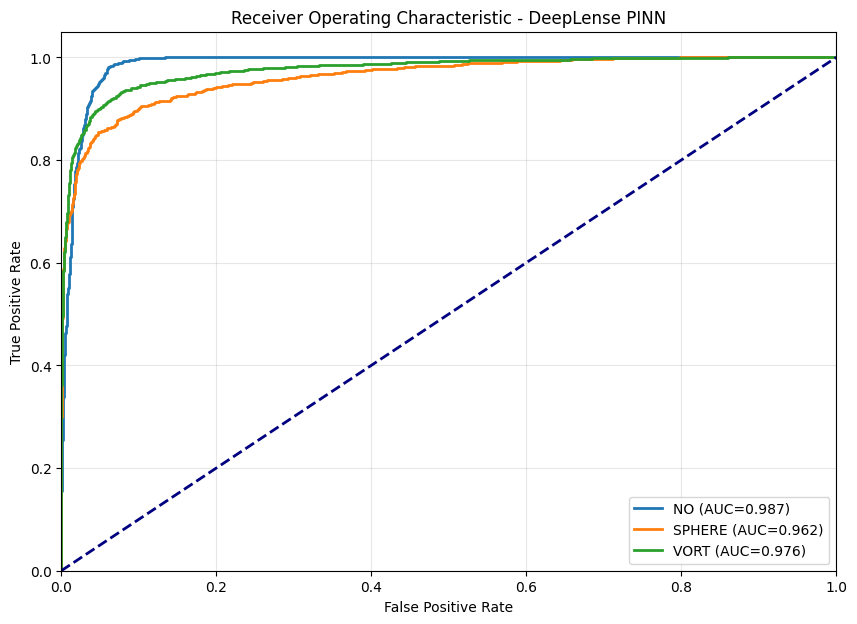

In [5]:
def evaluate_and_plot(config, dev):
    model = LensingPINN(config).to(dev)
    model.load_state_dict(torch.load(config.artifact_dir / "gsoc_pinn_best.pth", map_location=dev))
    model.eval()
    
    _, val_loader = get_stratified_loaders(config)
    y_true, y_probs = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            logits, _, _ = model(imgs.to(dev))
            y_true.extend(lbls.numpy()); y_probs.extend(torch.softmax(logits, dim=1).cpu().numpy())
    
    y_true, y_probs = np.array(y_true), np.array(y_probs)
    
    plt.figure(figsize=(10, 7))
    for i, name in enumerate(config.class_mapping.keys()):
        fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_probs[:, i])
        plt.plot(fpr, tpr, lw=2, label=f"{name.upper()} (AUC={auc(fpr, tpr):.3f})")
    
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic - DeepLense PINN')
    plt.legend(loc="lower right"); plt.grid(alpha=0.3)
    plt.show()

evaluate_and_plot(config, device)